In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv


In [2]:
# California Housing
housing = pd.read_csv("/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv")
print(housing.info())
print(housing.describe())
print(housing.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952

In [3]:
# Fix missing values — fill with median 
housing['total_bedrooms'].fillna(housing['total_bedrooms'].median(), inplace=True)

# Confirm no more nulls
print(housing.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


/tmp/ipykernel_16/3348545641.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing['total_bedrooms'].fillna(housing['total_bedrooms'].median(), inplace=True)


In [4]:
#  stastics of the households
housing['rooms_per_household']    = housing['total_rooms'] / housing['households']
housing['bedrooms_per_room']      = housing['total_bedrooms'] / housing['total_rooms']
housing['population_per_household'] = housing['population'] / housing['households']

print(housing[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe())


       rooms_per_household  bedrooms_per_room  population_per_household
count         20640.000000       20640.000000              20640.000000
mean              5.429000           0.213794                  3.070655
std               2.474173           0.065248                 10.386050
min               0.846154           0.037151                  0.692308
25%               4.440716           0.175225                  2.429741
50%               5.229129           0.203159                  2.818116
75%               6.052381           0.240126                  3.282261
max             141.909091           2.824675               1243.333333


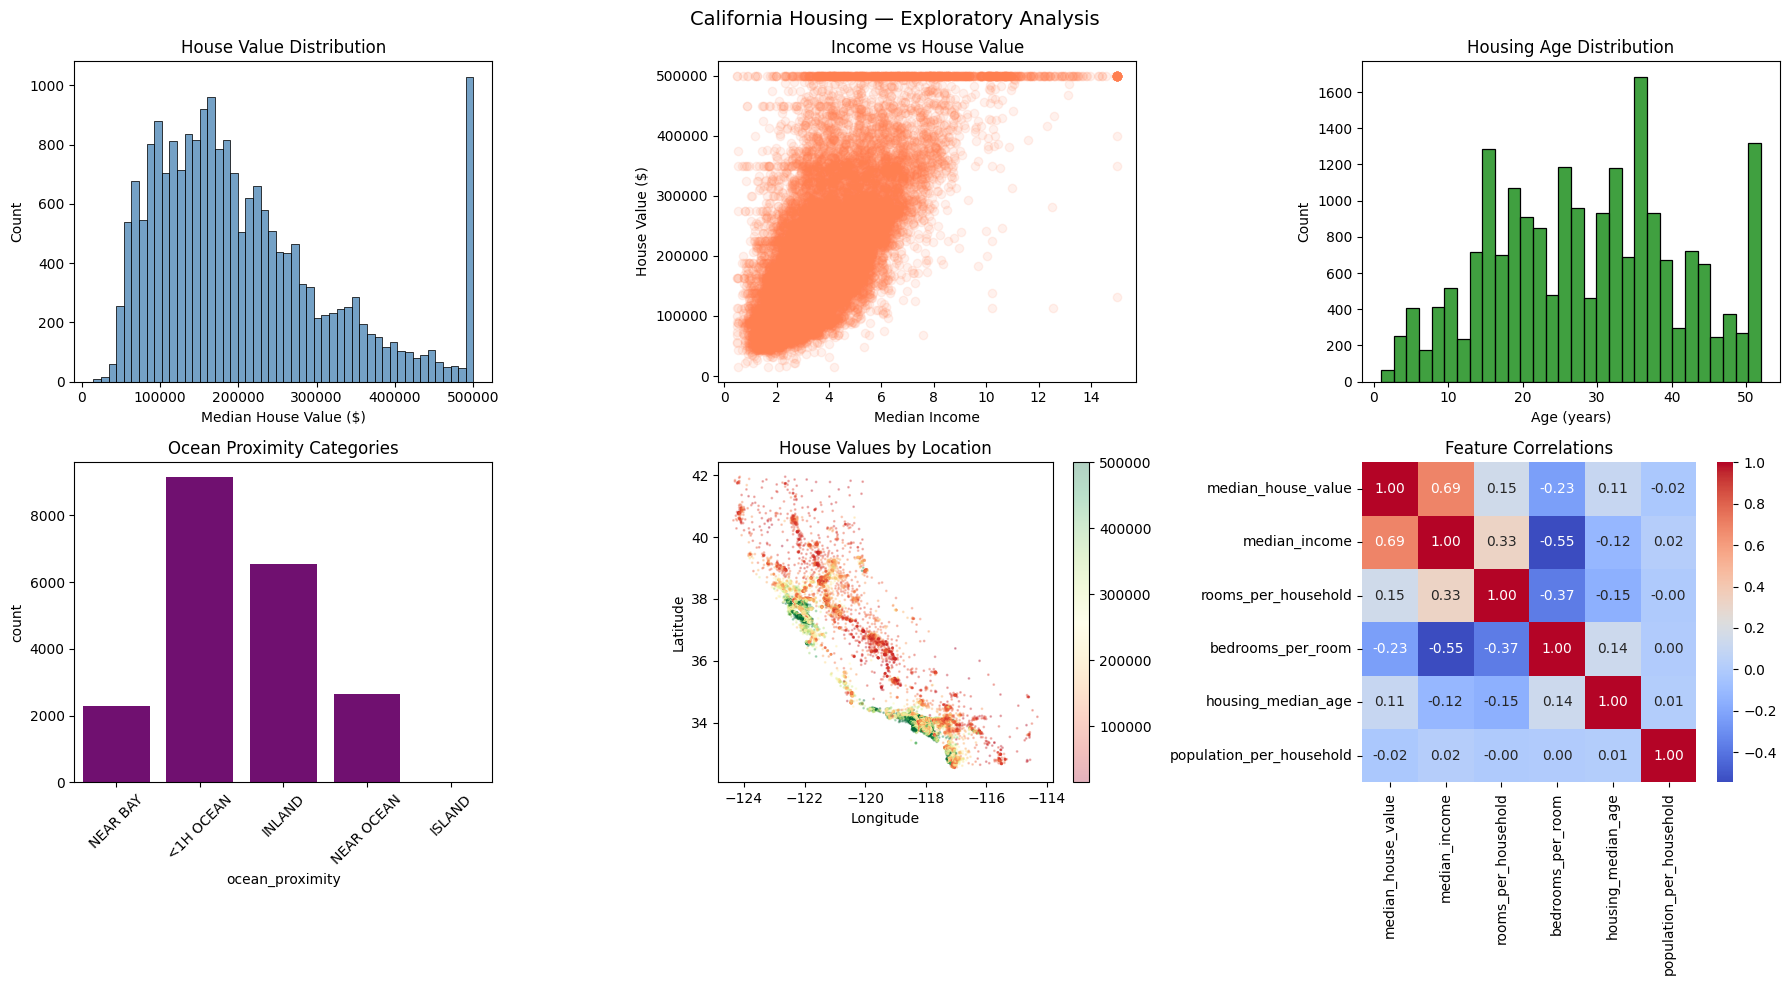

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('California Housing — Exploratory Analysis', fontsize=14)

#  House value distribution
sns.histplot(housing['median_house_value'], ax=axes[0,0], color='steelblue', bins=50)
axes[0,0].set_title('House Value Distribution')
axes[0,0].set_xlabel('Median House Value ($)')

#  Income vs House Value
axes[0,1].scatter(housing['median_income'], housing['median_house_value'], 
                  alpha=0.1, color='coral')
axes[0,1].set_title('Income vs House Value')
axes[0,1].set_xlabel('Median Income')
axes[0,1].set_ylabel('House Value ($)')

# House age distribution
sns.histplot(housing['housing_median_age'], ax=axes[0,2], color='green', bins=30)
axes[0,2].set_title('Housing Age Distribution')
axes[0,2].set_xlabel('Age (years)')

#  Ocean proximity counts
sns.countplot(data=housing, x='ocean_proximity', ax=axes[1,0], color='purple')
axes[1,0].set_title('Ocean Proximity Categories')
axes[1,0].tick_params(axis='x', rotation=45)

#Geographic heatmap
scatter = axes[1,1].scatter(
    housing['longitude'], housing['latitude'],
    c=housing['median_house_value'],
    cmap='RdYlGn', alpha=0.3, s=1
)
plt.colorbar(scatter, ax=axes[1,1])
axes[1,1].set_title('House Values by Location')
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')

# Correlation heatmap
corr = housing[['median_house_value','median_income','rooms_per_household',
                'bedrooms_per_room','housing_median_age','population_per_household']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Feature Correlations')

plt.tight_layout()
plt.show()